## Goal
Use embeddings + clustering (unsupervised ML) to group related procedural paragraphs into logical "classes" or modules.

This shows the **unsupervised learning** component of the project.

In [1]:
# Cell 1: Setup
import sys
sys.path.append('..')
from src.cobol_parser import parse_cobol
from src.models import cluster_procedural_patterns, CodeEmbedder
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Parse example
parsed = parse_cobol('../data/simple_account.cbl')
paragraph_texts = [text.strip() for _, text in parsed['raw_paragraphs'] if text.strip()]
print("Extracted paragraph texts for clustering:")
for i, text in enumerate(paragraph_texts):
    print(f"{i}: {text[:100]}...")

c:\Users\misap\.conda\envs\cs422\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracted paragraph texts for clustering:
0: DATA...
1: WORKING-STORAGE...
2: 01...
3: 05 ACCOUNT-NUMBER     PIC 9(10).
   05 ACCOUNT-BALANCE    PIC S9(10)...
4: 05 ACCOUNT-OWNER      PIC X(50).
   05 TRANSACTION-AMOUNT PIC S9(8)...
5: PROCEDURE...
6: PERFORM...
7: PERFORM...
8: PERFORM...
9: ADD TRANSACTION-AMOUNT TO...
10: DISPLAY "DEPOSIT PROCESSED FOR ACCOUNT "...
11: SUBTRACT TRANSACTION-AMOUNT FROM...
12: DISPLAY "WITHDRAWAL PROCESSED FOR ACCOUNT "...
13: DISPLAY "ACCOUNT BALANCE REPORT: "...


In [2]:
# Cell 2: Clustering
clusters = cluster_procedural_patterns(paragraph_texts, n_clusters=2)
print("Cluster assignments:", clusters)

# Simple visualization of clusters
for i, (cluster_id, text) in enumerate(zip(clusters, paragraph_texts)):
    print(f"Cluster {cluster_id}: {parsed['potential_methods'][i]}")

Cluster assignments: [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Cluster 1: DIVISION
Cluster 1: PROGRAM
Cluster 1: ACCOUNT
Cluster 1: DIVISION
Cluster 1: SECTION
Cluster 0: ACCOUNT
Cluster 1: V99
Cluster 1: V99
Cluster 1: DIVISION
Cluster 1: MAIN
Cluster 1: PROCESS
Cluster 1: PROCESS
Cluster 1: GENERATE
Cluster 1: RUN


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10252.83it/s]


Number of paragraphs: 14
Number of clusters: 14
Method names: ['DIVISION', 'PROGRAM', 'ACCOUNT', 'DIVISION', 'SECTION', 'ACCOUNT', 'V99', 'V99', 'DIVISION', 'MAIN', 'PROCESS', 'PROCESS', 'GENERATE', 'RUN', 'PROCESS', 'ACCOUNT', 'ACCOUNT', 'PROCESS', 'ACCOUNT', 'ACCOUNT', 'GENERATE']


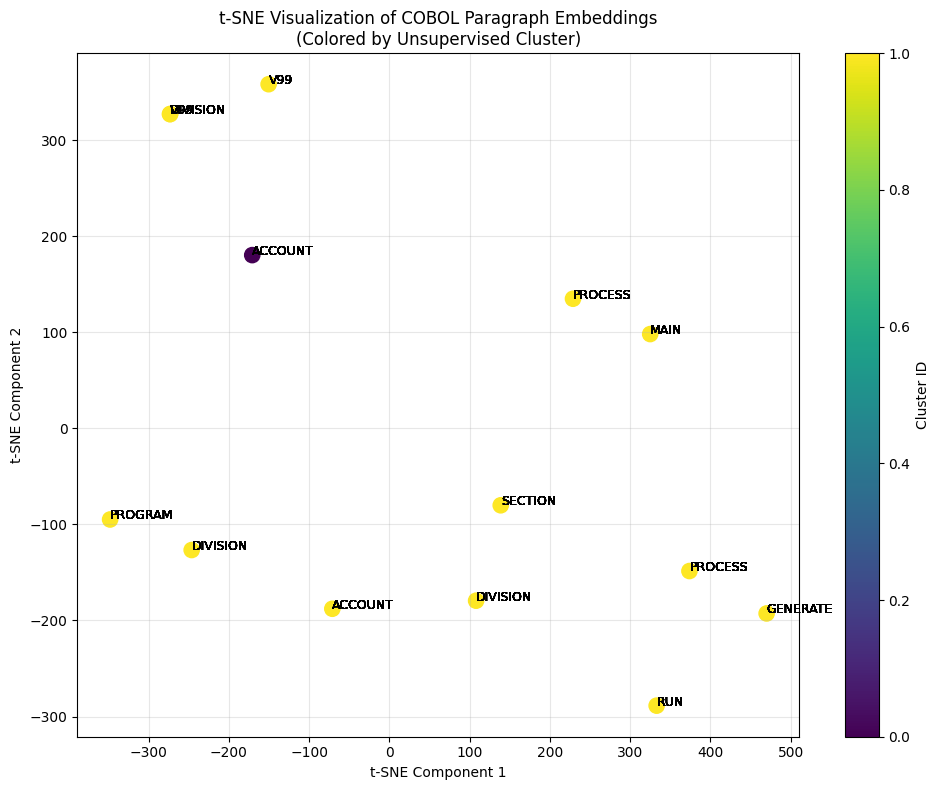

In [6]:
# Cell 3: Embedding visualization (t-SNE) - FIXED
embedder = CodeEmbedder()
embeddings = embedder.embed_texts(paragraph_texts)

# Safe t-SNE (handles small number of samples)
n_samples = len(paragraph_texts)
perplexity = min(5, max(1, n_samples - 1))   # perplexity must be < n_samples

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
reduced = tsne.fit_transform(embeddings)

# Use consistent data source for labels (from raw_paragraphs)
method_names = [name for name, _ in parsed['raw_paragraphs']]

print(f"Number of paragraphs: {len(paragraph_texts)}")
print(f"Number of clusters: {len(clusters)}")
print(f"Method names: {method_names}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis', s=120)

plt.colorbar(scatter, label='Cluster ID')
for i, txt in enumerate(method_names):
    for i, txt in enumerate(method_names[:len(reduced)]):
        plt.annotate(txt, (reduced[i, 0] + 0.02, reduced[i, 1] + 0.02), 
                     fontsize=9, alpha=0.9)

plt.title('t-SNE Visualization of COBOL Paragraph Embeddings\n(Colored by Unsupervised Cluster)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()